TIỀN XỬ LÝ DỮ LIỆU

In [1]:
import os
import shutil
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
from tqdm import tqdm

In [ ]:
# === CẤU HÌNH THƯ MỤC ===
RAW_DATA_DIR   = "D:/Do_An/Data_Raw"    
DATA_DIR       = "D:/Do_An/Data"        
BLACKLIST_FILE = 'blacklist.txt'         
FINAL_DATA_DIR = "D:/Do_An/Data_Final"  

# === CẤU HÌNH ẢNH ===
IMG_SIZE       = (224, 224)
ZOOM_FACTOR    = 2.0
BATCH_SIZE     = 32
SEED           = 123

In [3]:
# 1. Loại bỏ ảnh rò rỉ
blacklist = set()
if os.path.exists(BLACKLIST_FILE):
    with open(BLACKLIST_FILE, 'r', encoding='utf-8') as f:
        for line in f:
            path = line.strip()
            if path:
                # Chuẩn hoá dấu gạch chéo để so sánh
                blacklist.add(os.path.normpath(path))
    print(f"Đã đọc blacklist: {len(blacklist)} đường dẫn bị loại.")
else:
    print("Không tìm thấy blacklist.txt → sẽ copy TẤT CẢ ảnh từ Data_Raw.")

os.makedirs(DATA_DIR, exist_ok=True)

# Duyệt qua Data_Raw 
VALID_EXTS = ('.jpg', '.jpeg', '.png', '.bmp')

count_copied  = 0
count_skipped = 0

all_files = []
for root, dirs, files in os.walk(RAW_DATA_DIR):
    for file in files:
        if file.lower().endswith(VALID_EXTS):
            all_files.append(os.path.join(root, file))

for src_path in tqdm(all_files, desc="Lọc & Copy"):
    norm_src = os.path.normpath(src_path)
    if norm_src in blacklist:
        count_skipped += 1
        continue

    # Tính đường dẫn đích giữ nguyên cấu trúc con
    rel_path = os.path.relpath(src_path, RAW_DATA_DIR)
    dst_path = os.path.join(DATA_DIR, rel_path)
    os.makedirs(os.path.dirname(dst_path), exist_ok=True)

    shutil.copy2(src_path, dst_path)
    count_copied += 1

print(f"\nĐã copy {count_copied} ảnh sạch vào '{DATA_DIR}'.")
print(f" Bỏ qua  {count_skipped} ảnh trùng lặp / rò rỉ.")

# Đổi tên blacklist để đánh dấu đã xử lý
if os.path.exists(BLACKLIST_FILE):
    done_file = BLACKLIST_FILE.replace('.txt', '_DONE.txt')
    os.rename(BLACKLIST_FILE, done_file)
    print(f"   Đã đổi tên '{BLACKLIST_FILE}' → '{done_file}'.")

Đã đọc blacklist: 459 đường dẫn bị loại.


Lọc & Copy:   0%|          | 0/3268 [00:00<?, ?it/s]

Lọc & Copy: 100%|██████████| 3268/3268 [00:05<00:00, 652.23it/s] 


Đã copy 2810 ảnh sạch vào 'D:/Do_An/Data'.
 Bỏ qua  458 ảnh trùng lặp / rò rỉ.
   Đã đổi tên 'blacklist.txt' → 'blacklist_DONE.txt'.


In [4]:
# Thống kê ảnh 
print(f"{'TẬP':<8} | {'LỚP':<10} | {'SỐ ẢNH':<10}")
print("-" * 35)

total = 0
for split in os.listdir(DATA_DIR):
    split_path = os.path.join(DATA_DIR, split)
    if not os.path.isdir(split_path):
        continue
    for label in os.listdir(split_path):
        label_path = os.path.join(split_path, label)
        if not os.path.isdir(label_path):
            continue
        imgs = [f for f in os.listdir(label_path)
                if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
        count = len(imgs)
        total += count
        print(f"{split:<8} | {label:<10} | {count:<10}")

print("-" * 35)
print(f"Tổng cộng: {total} ảnh")

TẬP      | LỚP        | SỐ ẢNH    
-----------------------------------
test     | fresh      | 356       
test     | rotten     | 450       
train    | fresh      | 935       
train    | rotten     | 1069      
-----------------------------------
Tổng cộng: 2810 ảnh


In [5]:
def extract_meat_bbox(img):
    try:
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

        # ===== 1. MASK ĐỎ (thịt) =====
        lower1 = np.array([0, 80, 50])
        upper1 = np.array([10, 255, 180])

        lower2 = np.array([170, 80, 50])
        upper2 = np.array([180, 255, 180])

        mask = cv2.bitwise_or(
            cv2.inRange(hsv, lower1, upper1),
            cv2.inRange(hsv, lower2, upper2)
        )

        # ===== 2. MORPHOLOGY =====
        kernel = np.ones((5,5), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        mask = cv2.dilate(mask, kernel, iterations=2)

        # ===== 3. CONTOUR =====
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if not contours:
            return None

        H, W = img.shape[:2]
        cx_img, cy_img = W // 2, H // 2

        best_c = None
        best_score = -1

        for c in contours:
            area = cv2.contourArea(c)

            # bỏ nhiễu nhỏ
            if area < 500:
                continue

            x, y, w, h = cv2.boundingRect(c)

            # ===== 4. BỎ VÙNG SÁT BIÊN (tay người thường ở đây) =====
            margin = 20
            if x < margin or y < margin or (x+w) > (W-margin) or (y+h) > (H-margin):
                continue

            # ===== 5. CHECK ĐỘ ĐỎ THẬT (loại tay + nền) =====
            mask_temp = np.zeros(mask.shape, dtype=np.uint8)
            cv2.drawContours(mask_temp, [c], -1, 255, -1)

            mean_color = cv2.mean(img, mask=mask_temp)  # BGR
            B, G, R = mean_color[:3]

            if not (R > 1.3 * G and R > 1.3 * B):
                continue

            # ===== 6. ƯU TIÊN GẦN CENTER =====
            cx = x + w // 2
            cy = y + h // 2

            dist = np.sqrt((cx - cx_img)**2 + (cy - cy_img)**2)

            # score cuối
            score = area * 1.5 - dist

            if score > best_score:
                best_score = score
                best_c = c

        if best_c is None:
            return None

        # ===== 7. CROP + PADDING =====
        x, y, w, h = cv2.boundingRect(best_c)

        pad = int(0.2 * max(w, h))

        x1 = max(0, x - pad)
        y1 = max(0, y - pad)
        x2 = min(W, x + w + pad)
        y2 = min(H, y + h + pad)

        cropped = img[y1:y2, x1:x2]

        return cropped

    except Exception as e:
        print("Lỗi extract:", e)
        return None

# PIPELINE CHÍNH
def process_dataset(data_dir, save_dir):
    all_imgs = []

    for root, _, files in os.walk(data_dir):
        for file in files:
            if file.lower().endswith(('.jpg', '.png', '.jpeg')):
                all_imgs.append(os.path.join(root, file))

    count_ok = 0
    count_removed = 0

    with tqdm(total=len(all_imgs), desc="Processing") as pbar:
        for img_path in all_imgs:
            try:
                img = cv2.imread(img_path)

                if img is None:
                    count_removed += 1
                    pbar.update(1)
                    continue

                result = extract_meat_bbox(img)

                if result is None:
                    count_removed += 1
                    pbar.update(1)
                    continue

                # resize chuẩn cho model
                result = cv2.resize(result, IMG_SIZE)

                save_path = img_path.replace(data_dir, save_dir)
                os.makedirs(os.path.dirname(save_path), exist_ok=True)

                cv2.imwrite(save_path, result)
                count_ok += 1

            except Exception as e:
                print("Lỗi:", img_path, e)

            pbar.update(1)

    print("\nHOÀN TẤT")
    print(f"Ảnh giữ lại : {count_ok}")
    print(f"Ảnh bị loại : {count_removed}")

DATA_DIR = "D:/Do_An/Data"
SAVE_DIR = "D:/Do_An/Data_Final"

process_dataset(DATA_DIR, SAVE_DIR)

Processing: 100%|██████████| 2810/2810 [05:09<00:00,  9.07it/s] 


HOÀN TẤT
Ảnh giữ lại : 2613
Ảnh bị loại : 197


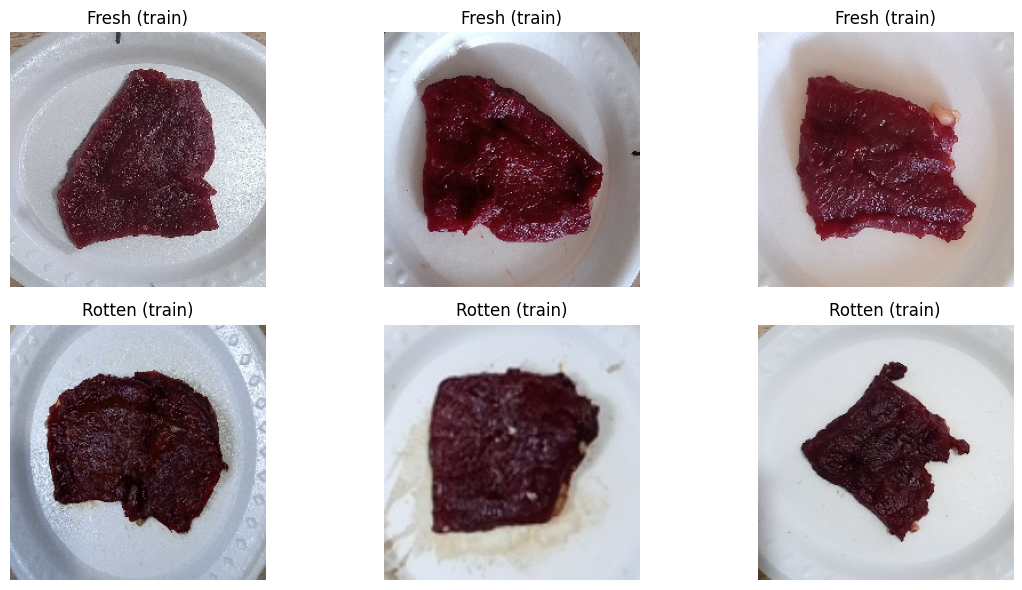

In [6]:
# Hiển thị ảnh ngẫu nhiên từ Data để xác nhận
def get_images_from_folder(folder, num=3):
    if not os.path.exists(folder):
        print(f"Không tồn tại: {folder}")
        return []

    imgs = [os.path.join(folder, f) for f in os.listdir(folder)
            if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

    if len(imgs) == 0:
        return []

    return random.sample(imgs, min(num, len(imgs)))


def show_fresh_rotten(data_dir, split="train"):
    fresh_dir = os.path.join(data_dir, split, "fresh")
    rotten_dir = os.path.join(data_dir, split, "rotten")

    fresh_imgs = get_images_from_folder(fresh_dir, 3)
    rotten_imgs = get_images_from_folder(rotten_dir, 3)

    plt.figure(figsize=(12, 6))

    for i, img_path in enumerate(fresh_imgs):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        plt.title(f"Fresh ({split})")
        plt.axis("off")

    for i, img_path in enumerate(rotten_imgs):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(2, 3, i + 4)
        plt.imshow(img)
        plt.title(f"Rotten ({split})")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

DATA_DIR = "D:/Do_An/Data_Final"

show_fresh_rotten(DATA_DIR)